In [ ]:
!pip install geopandas rasterio pysheds shapely matplotlib fiona pyogrio -q
import os
import gc
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
import fiona
from rasterio.windows import from_bounds
from pysheds.grid import Grid
from shapely.geometry import box
from google.colab import drive

drive.mount('/content/drive')
path_tif = '/content/drive/MyDrive/DATA/MDT/DTM_2024_merged_Mare.tif'
path_geojson = '/content/drive/MyDrive/DATA/Vetores/Hidrografia.geojson'
path_gpkg = '/content/drive/MyDrive/DATA/Vetores/buildings(SHX).gpkg'

#Timbau
min_x, max_x = 679748, 680840 #680870, 679760
min_y, max_y = 7470300, 7471018 #7470754, 7471676

#Nova Holanda
#min_x, max_x = 679777, 680880
#min_y, max_y = 7470754, 7471676

bbox_geom = box(min_x, min_y, max_x, max_y)

layers = fiona.listlayers(path_gpkg)
layer_name = layers[0]

predios_full = gpd.read_file(
    path_gpkg,
    layer=layer_name
)

predios_full.columns = (
    predios_full.columns
    .str.lower()
    .str.strip()
)

predios_full["geometry"] = (predios_full.geometry.force_2d())
rios_full = gpd.read_file(path_geojson)

print("\n Estatísticas da população:")
print(predios_full['pop_casa'].describe())
print("\nSoma total da população:",predios_full['pop_casa'].sum())

with rasterio.open(path_tif) as src:
    if predios_full.crs != src.crs:
        predios_full = predios_full.to_crs(src.crs)

    if rios_full.crs != src.crs:
        rios_full = rios_full.to_crs(src.crs)

    print("\nBounds do raster:")
    print(src.bounds)

    window = from_bounds(
        min_x,
        min_y,
        max_x,
        max_y,
        src.transform
    )

    out_image = src.read(1, window=window)
    out_transform = src.window_transform(window)
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[0],
        "width": out_image.shape[1],
        "transform": out_transform,
        "compress": "lzw"
    })

path_clip = 'MDT_clip.tif'

with rasterio.open(path_clip, "w", **out_meta) as dest:
    dest.write(out_image, 1)

predios = predios_full[
    predios_full.intersects(bbox_geom)
].copy()

rios = rios_full[
    rios_full.intersects(bbox_geom)
].copy()

print(f"\Prédios encontrados: {len(predios)}")
print(f"Rios encontrados: {len(rios)}")

if predios.empty:
    raise ValueError("Nenhum prédio encontrado na área.")

if rios.empty:
    raise ValueError("Nenhum rio encontrado na área.")

print("\nPopulação total na área:", predios['pop_casa'].sum())

del out_image
gc.collect()

grid = Grid.from_raster(path_clip)
dem = grid.read_raster(path_clip)

print("MDT carregado")

<>:92: SyntaxWarning: invalid escape sequence '\P'
<>:92: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_28677/3720542278.py:92: SyntaxWarning: invalid escape sequence '\P'
  print(f"\Prédios encontrados: {len(predios)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 Estatísticas da população:
count    21760.000000
mean         5.733502
std          6.842102
min          0.000000
25%          3.000000
50%          4.000000
75%          7.000000
max        167.000000
Name: pop_casa, dtype: float64

Soma total da população: 124761.0

Bounds do raster:
BoundingBox(left=676342.3163, bottom=7466901.0306, right=682794.2663, top=7473908.2806)
\Prédios encontrados: 3876
Rios encontrados: 2

População total na área: 16801.0
MDT carregado


<>:79: SyntaxWarning: invalid escape sequence '\S'
<>:79: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_28677/3268496389.py:79: SyntaxWarning: invalid escape sequence '\S'
  print("\Simulando inundação...")



Corrigindo DEM...
DEM corrigido

Calculando Flow Direction...
Flow Direction calculada

Rasterizando rios...
Rasterização concluída

Calculando HAND...
HAND calculado


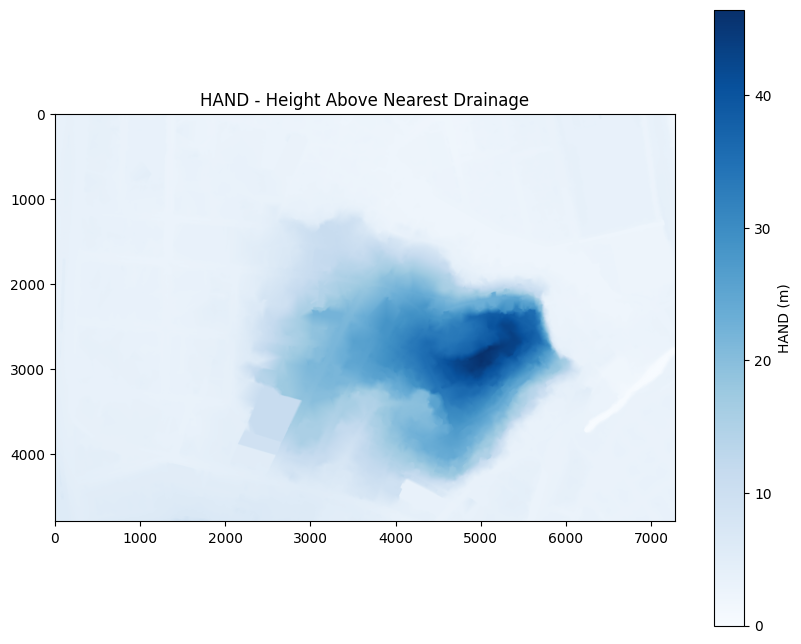


Soma total população: 16801

Extraindo HAND dos prédios...

Estatísticas HAND:
count                  3875
unique                 3726
top       2.080007979735612
freq                     13
Name: min_hand, dtype: object
\Simulando inundação...

Nível 1.50 m
Prédios afetados: 0
População afetada: 0

Nível 1.75 m
Prédios afetados: 2
População afetada: 18

Nível 2.00 m
Prédios afetados: 13
População afetada: 157

Nível 2.25 m
Prédios afetados: 398
População afetada: 1733

Nível 2.50 m
Prédios afetados: 681
População afetada: 3029

Nível 2.75 m
Prédios afetados: 1021
População afetada: 4619

Nível 3.00 m
Prédios afetados: 1364
População afetada: 6409

Nível 3.25 m
Prédios afetados: 1803
População afetada: 8409

Nível 3.50 m
Prédios afetados: 2002
População afetada: 9186

Nível 3.75 m
Prédios afetados: 2099
População afetada: 9536

Nível 4.00 m
Prédios afetados: 2142
População afetada: 9678


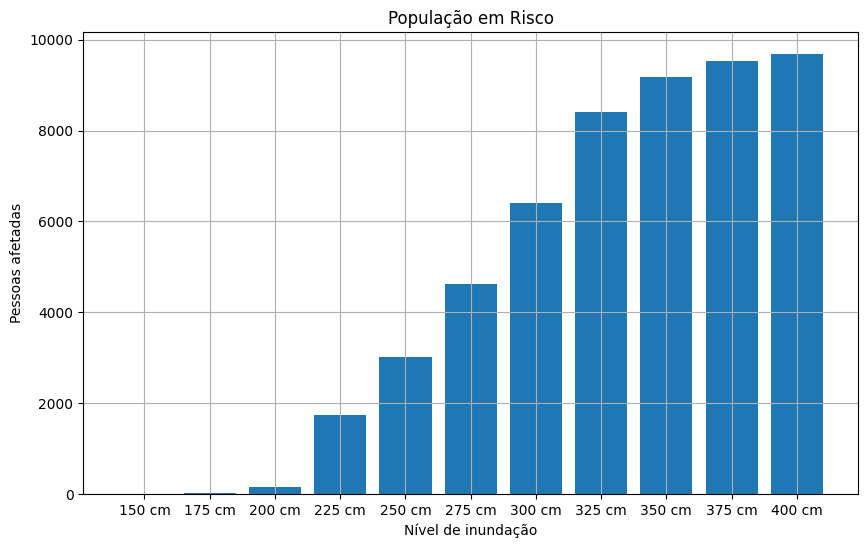


Concluido


In [ ]:
print("\nCorrigindo DEM...")
dem = grid.fill_pits(dem)
dem = grid.fill_depressions(dem)
dem = grid.resolve_flats(dem)
print("DEM corrigido")


print("\nCalculando Flow Direction...")
fdir = grid.flowdir(dem)
print("Flow Direction calculada")

print("\nRasterizando rios...")
rios_raster = grid.rasterize(rios.geometry)
print("Rasterização concluída")

print("\nCalculando HAND...")
river_mask = rios_raster > 0
hand = np.full(dem.shape, np.nan)
river_elevation = np.where(
    river_mask,
    dem,
    np.nan
)

min_river_elev = np.nanmin(
    river_elevation
)

hand = dem - min_river_elev
hand[hand < 0] = 0
print("HAND calculado")

plt.figure(figsize=(10,8))
plt.imshow(hand, cmap='Blues')
plt.colorbar(label='HAND (m)')
plt.title('HAND - Height Above Nearest Drainage')
plt.show()

predios['pop_casa'] = (
    predios['pop_casa']
    .fillna(0)
    .astype(int)
)

print("\nSoma total população:", predios['pop_casa'].sum())

print("\nExtraindo HAND dos prédios...")
from rasterio.features import geometry_mask
with rasterio.open(path_clip) as src:
    affine = src.transform
    hand_values = []
    for geom in predios.geometry:
        try:
            mask_geom = geometry_mask(
                [geom],
                transform=affine,
                invert=True,
                out_shape=hand.shape
            )

            values = hand[mask_geom]
            values = values[
                ~np.isnan(values)
            ]

            if len(values) == 0:
                hand_values.append(np.nan)
            else:
                hand_values.append(np.min(values))

        except:
            hand_values.append(np.nan)

predios['min_hand'] = hand_values

print("\nEstatísticas HAND:")
print(predios['min_hand'].describe())

print("\Simulando inundação...")
niveis_chuva = [
    1.5,
    1.75,
    2,
    2.25,
    2.5,
    2.75,
    3,
    3.25,
    3.5,
    3.75,
    4
]
pop_afetada = []
for nivel in niveis_chuva:
    afetados = predios[
        predios['min_hand'] <= nivel
    ]
    total = afetados[
        'pop_casa'
    ].sum()
    pop_afetada.append(total)
    print(f"\nNível {nivel:.2f} m")
    print(f"Prédios afetados: {len(afetados)}")
    print(f"População afetada: {total}")

plt.figure(figsize=(10,6))
plt.bar(
    [
        f"{int(n*100)} cm"
        for n in niveis_chuva
    ],
    pop_afetada
)

plt.title('População em Risco')
plt.xlabel('Nível de inundação')
plt.ylabel('Pessoas afetadas')
plt.grid(True)
plt.show()
print("\nConcluido")

In [ ]:
pop_afetada

[np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]